In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel(r"C:\Users\HP\Desktop\PROJECT\smart_mining_equipment_dataset.xlsx")
print(df.head())

            Machine Failure_Type  Downtime_Hours Maintenance_Type Shift  \
0  Continuous Miner    Hydraulic            4.48       Preventive     A   
1               LHD    Hydraulic            2.13       Corrective     A   
2         Excavator   Mechanical            6.14       Corrective     C   
3         Excavator         Tire            6.66       Preventive     A   
4  Continuous Miner       Engine            5.89       Preventive     C   

        Date  
0 2025-01-01  
1 2025-01-02  
2 2025-01-03  
3 2025-01-04  
4 2025-01-05  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Machine           200 non-null    object        
 1   Failure_Type      200 non-null    object        
 2   Downtime_Hours    200 non-null    float64       
 3   Maintenance_Type  200 non-null    object        
 4   Shift             200 non-null    object        
 5   Date              200 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 9.5+ KB
None


In [4]:
print(df.isnull().sum())

Machine             0
Failure_Type        0
Downtime_Hours      0
Maintenance_Type    0
Shift               0
Date                0
dtype: int64


In [5]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [6]:
df = df.drop_duplicates()

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

In [8]:
print(df.dtypes)

Machine                     object
Failure_Type                object
Downtime_Hours             float64
Maintenance_Type            object
Shift                       object
Date                datetime64[ns]
dtype: object


In [9]:
print(df.describe())

       Downtime_Hours                 Date
count      200.000000                  200
mean         4.558350  2025-04-10 12:00:00
min          1.030000  2025-01-01 00:00:00
25%          2.872500  2025-02-19 18:00:00
50%          4.395000  2025-04-10 12:00:00
75%          6.515000  2025-05-30 06:00:00
max          7.940000  2025-07-19 00:00:00
std          2.068456                  NaN


In [10]:
df.to_excel("cleaned_mining_equipment_dataset.xlsx", index=False)

In [11]:
import matplotlib.pyplot as plt
df = pd.read_excel(r"C:\Users\HP\Desktop\PROJECT\cleaned_mining_equipment_dataset.xlsx")
print(df.head())

            Machine Failure_Type  Downtime_Hours Maintenance_Type Shift  \
0  Continuous Miner    Hydraulic            4.48       Preventive     A   
1               LHD    Hydraulic            2.13       Corrective     A   
2         Excavator   Mechanical            6.14       Corrective     C   
3         Excavator         Tire            6.66       Preventive     A   
4  Continuous Miner       Engine            5.89       Preventive     C   

        Date  
0 2025-01-01  
1 2025-01-02  
2 2025-01-03  
3 2025-01-04  
4 2025-01-05  


In [12]:
machine_downtime = df.groupby("Machine")["Downtime_Hours"].sum()
print(machine_downtime)

Machine
Continuous Miner    185.62
Drill Rig           179.93
Dumper              151.78
Excavator           224.09
LHD                 170.25
Name: Downtime_Hours, dtype: float64


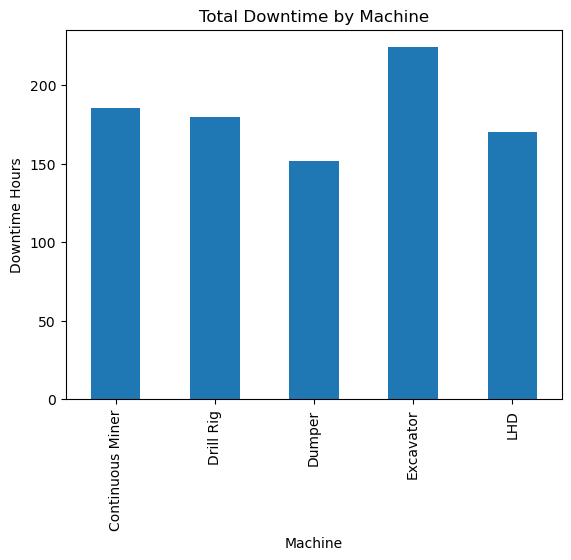

In [13]:
machine_downtime.plot(kind="bar")
plt.title("Total Downtime by Machine")
plt.xlabel("Machine")
plt.ylabel("Downtime Hours")
plt.show()

In [14]:
failure_count = df["Failure_Type"].value_counts()
print(failure_count)

Failure_Type
Hydraulic     66
Engine        46
Mechanical    38
Electrical    32
Tire          18
Name: count, dtype: int64


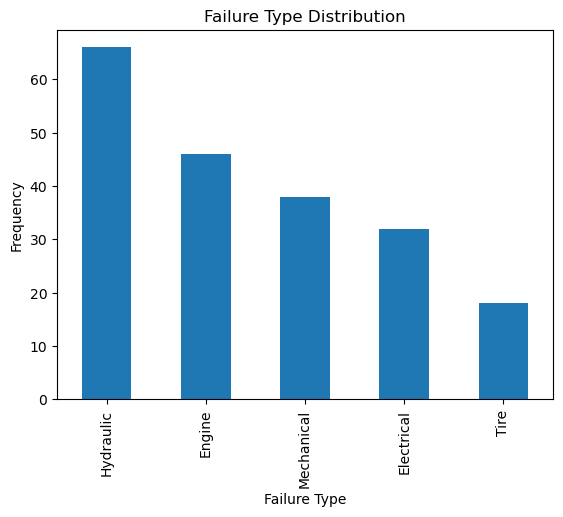

In [15]:
failure_count.plot(kind="bar")
plt.title("Failure Type Distribution")
plt.xlabel("Failure Type")
plt.ylabel("Frequency")
plt.show()

In [16]:
maintenance_analysis = df.groupby("Maintenance_Type")["Downtime_Hours"].sum()
print(maintenance_analysis)

Maintenance_Type
Corrective    522.89
Preventive    388.78
Name: Downtime_Hours, dtype: float64


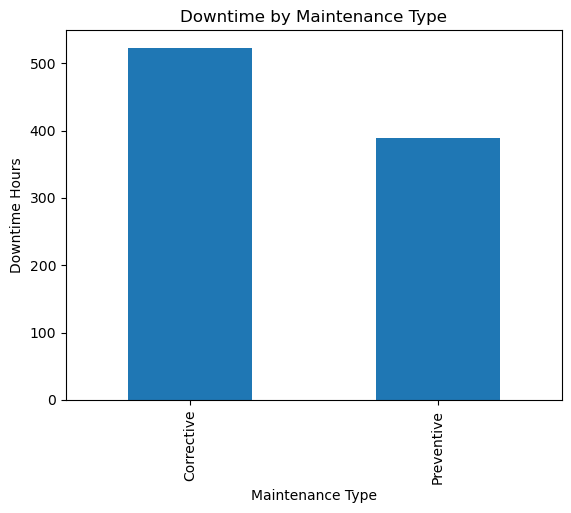

In [17]:
maintenance_analysis.plot(kind="bar")
plt.title("Downtime by Maintenance Type")
plt.xlabel("Maintenance Type")
plt.ylabel("Downtime Hours")
plt.show()

In [18]:
shift_downtime = df.groupby("Shift")["Downtime_Hours"].sum()
print(shift_downtime)

Shift
A    318.75
B    360.14
C    232.78
Name: Downtime_Hours, dtype: float64


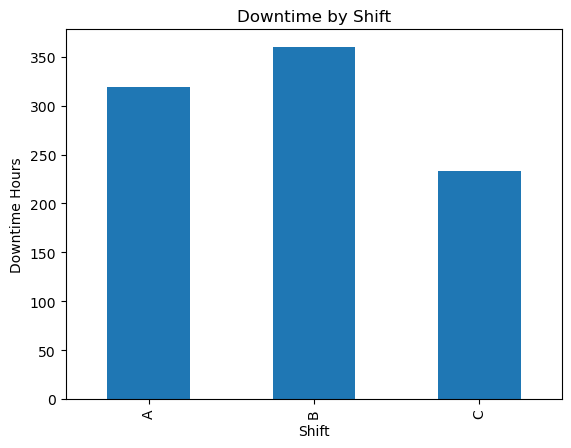

In [19]:
shift_downtime.plot(kind="bar")
plt.title("Downtime by Shift")
plt.xlabel("Shift")
plt.ylabel("Downtime Hours")
plt.show()

In [20]:
machine_failure = df["Machine"].value_counts()
print(machine_failure)

Machine
Continuous Miner    45
Excavator           43
Drill Rig           41
LHD                 40
Dumper              31
Name: count, dtype: int64


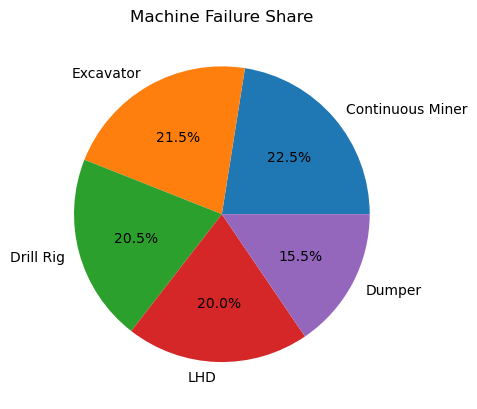

In [21]:
machine_failure.plot(kind="pie", autopct="%1.1f%%")
plt.title("Machine Failure Share")
plt.ylabel("")
plt.show()

In [22]:
daily_downtime = df.groupby("Date")["Downtime_Hours"].sum()
print(daily_downtime)

Date
2025-01-01    4.48
2025-01-02    2.13
2025-01-03    6.14
2025-01-04    6.66
2025-01-05    5.89
              ... 
2025-07-15    7.38
2025-07-16    4.05
2025-07-17    1.87
2025-07-18    2.91
2025-07-19    1.04
Name: Downtime_Hours, Length: 200, dtype: float64


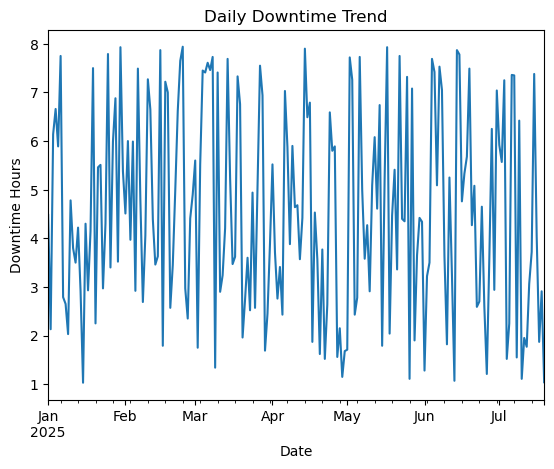

In [23]:
daily_downtime.plot()
plt.title("Daily Downtime Trend")
plt.xlabel("Date")
plt.ylabel("Downtime Hours")
plt.show()

In [24]:
print(df.head())

            Machine Failure_Type  Downtime_Hours Maintenance_Type Shift  \
0  Continuous Miner    Hydraulic            4.48       Preventive     A   
1               LHD    Hydraulic            2.13       Corrective     A   
2         Excavator   Mechanical            6.14       Corrective     C   
3         Excavator         Tire            6.66       Preventive     A   
4  Continuous Miner       Engine            5.89       Preventive     C   

        Date  
0 2025-01-01  
1 2025-01-02  
2 2025-01-03  
3 2025-01-04  
4 2025-01-05  


In [25]:
def risk_category(hours):   
    if hours <= 3:
        return "Low"    
    elif hours <= 6:
        return "Medium"   
    else:
        return "High"
df["Risk_Level"] = df["Downtime_Hours"].apply(risk_category)
print(df.head())

            Machine Failure_Type  Downtime_Hours Maintenance_Type Shift  \
0  Continuous Miner    Hydraulic            4.48       Preventive     A   
1               LHD    Hydraulic            2.13       Corrective     A   
2         Excavator   Mechanical            6.14       Corrective     C   
3         Excavator         Tire            6.66       Preventive     A   
4  Continuous Miner       Engine            5.89       Preventive     C   

        Date Risk_Level  
0 2025-01-01     Medium  
1 2025-01-02        Low  
2 2025-01-03       High  
3 2025-01-04       High  
4 2025-01-05     Medium  


In [26]:
risk_count = df["Risk_Level"].value_counts()
print(risk_count)

Risk_Level
Medium    86
Low       59
High      55
Name: count, dtype: int64


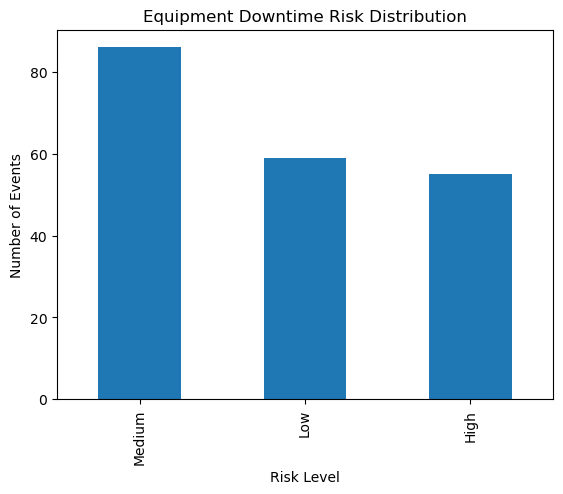

In [27]:
risk_count.plot(kind="bar")
plt.title("Equipment Downtime Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Events")
plt.show()

In [28]:
machine_risk = pd.crosstab(df["Machine"], df["Risk_Level"])
print(machine_risk)

Risk_Level        High  Low  Medium
Machine                            
Continuous Miner    12   21      12
Drill Rig            8   12      21
Dumper              11    6      14
Excavator           17    6      20
LHD                  7   14      19


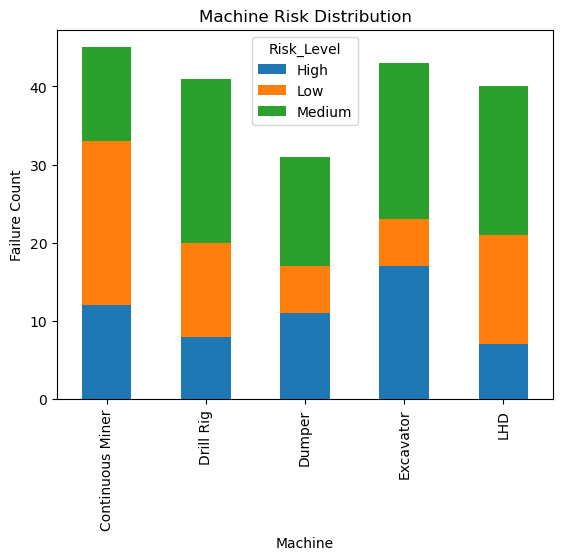

In [29]:
machine_risk.plot(kind="bar", stacked=True)
plt.title("Machine Risk Distribution")
plt.xlabel("Machine")
plt.ylabel("Failure Count")
plt.show()

In [30]:
df.to_excel("mining_equipment_risk_analysis.xlsx", index=False)